In [17]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import confusion_matrix
import lightgbm as lgb
from lightgbm import early_stopping
import time
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SavePlots = False

data = pd.DataFrame(np.genfromtxt('data_mice_encoded_aggr.csv', delimiter=',', names=True))

data["CLAIM_RATE"] = (
    data["CLAIM_COUNT"] / data["EXPOSURE"]
)

target = 'CLAIM_RATE'

features = [
    col for col in data.columns
    if col not in ['CLAIM_COUNT', 'CLAIM_SIZE', 'CLAIM_SIZE_INDEX', 
                   'f0', 'POLICY', 'EXPOSURE', 'OUTER_WALLS', 'HEATING_TYPE', 
                   'WATER_SUPPLY_TYPE', 'ROOF_TYPE', 'CLAIM_RATE']
]

data = data[data["EXPOSURE"] > 0]

X = data[features]
y = data[target]

feature_names = np.array(X.columns)

exposure = data["EXPOSURE"]


In [18]:
print(features)

['CONSTRUCTION_YEAR', 'BUILDINGS', 'FLOORS', 'WETROOMS', 'RESIDENTIAL_AREA', 'BASEMENT_AREA', 'CONSERVATORY_AREA', 'HOUDEN10KM', 'ROOF_TYPE_CAT_Brick', 'ROOF_TYPE_CAT_Concrete_Tiles', 'ROOF_TYPE_CAT_Fiber_Cement', 'ROOF_TYPE_CAT_Fiber_Cement_Asbestos', 'ROOF_TYPE_CAT_Flat_Roof', 'ROOF_TYPE_CAT_Glass', 'ROOF_TYPE_CAT_Metal_Sheets', 'ROOF_TYPE_CAT_Other_Material', 'ROOF_TYPE_CAT_PVC', 'ROOF_TYPE_CAT_Tar_Paper', 'ROOF_TYPE_CAT_Thatched_Roof', 'ROOF_TYPE_CAT_Unknown', 'WATER_SUPPLY_TYPE_CAT_Mixed_Water_Supply', 'WATER_SUPPLY_TYPE_CAT_No_Water_Supply', 'WATER_SUPPLY_TYPE_CAT_Non_Public_Water_Supply', 'WATER_SUPPLY_TYPE_CAT_Private_Water_Supply', 'WATER_SUPPLY_TYPE_CAT_Public_Water_Supply', 'WATER_SUPPLY_TYPE_CAT_Water_Extraction_Plant', 'WATER_SUPPLY_TYPE_CAT_Well_Water', 'HEATING_TYPE_CAT_Central_Heating_Own_System', 'HEATING_TYPE_CAT_Central_Heating_Two_Units', 'HEATING_TYPE_CAT_District_Heating', 'HEATING_TYPE_CAT_Electric_Heating', 'HEATING_TYPE_CAT_Gas_Radiators', 'HEATING_TYPE_CAT_Hea

In [ ]:
from __future__ import print_function, division

import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap

from tqdm.auto import tqdm
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

N_FOLDS = 3
N_SEEDS = 3
TOP_K = 10
PERM_REPEATS = 3

kf = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=582
)

cv_splits = list(kf.split(X))

seeds = list(range(N_SEEDS))

param_grid = [
    {"num_leaves": 10, "learning_rate": 0.03},
    {"num_leaves": 15, "learning_rate": 0.03},
    {"num_leaves": 25, "learning_rate": 0.03},
]

split_scores = []
gain_scores = []
perm_scores = []

topk_hits = {f: 0 for f in feature_names}
total_runs = 0

total_iterations = (
    len(param_grid)
    * len(seeds)
    * len(cv_splits)
)

pbar = tqdm(total=total_iterations, desc="Feature Ranking")

for params in param_grid:
    for seed in seeds:
        for fold, (train_idx, test_idx) in enumerate(cv_splits, start=1):

            # Split
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            w_train = exposure.iloc[train_idx]
            w_test = exposure.iloc[test_idx]

            # Modelling
            model = lgb.LGBMRegressor(
                objective="poisson",
                num_leaves=params["num_leaves"],
                learning_rate=params["learning_rate"],
                n_estimators=800,
                random_state=seed,
                n_jobs=-1,
                verbosity=-1
            )

            model.fit(
                X_train,
                y_train,
                sample_weight=w_train,
                eval_set=[(X_test, y_test)],
                eval_sample_weight=[w_test],
                callbacks=[
                    lgb.early_stopping(20, verbose=False)
                ]
            )

            booster = model.booster_

            # Feat. imp.: split
            split_scores.append(
                booster.feature_importance("split")
            )

            # Feat. imp.: gain
            gain_scores.append(
                booster.feature_importance("gain")
            )

            # Perm. imp.
            perm = permutation_importance(
                model,
                X_test,
                y_test,
                n_repeats=PERM_REPEATS,
                random_state=seed + fold,
                n_jobs=-1
            )

            perm_scores.append(
                perm.importances_mean
            )

            # Stability
            top_idx = np.argpartition(
                perm.importances_mean,
                -TOP_K
            )[-TOP_K:]

            for idx in top_idx:
                topk_hits[feature_names[idx]] += 1

            total_runs += 1
            pbar.update(1)

pbar.close()

split_mean = np.mean(split_scores, axis=0)
gain_mean = np.mean(gain_scores, axis=0)
perm_mean = np.mean(perm_scores, axis=0)

final = pd.DataFrame({
    "feature": feature_names,
    "split": split_mean,
    "gain": gain_mean,
    "perm": perm_mean
})

for col in ["split", "gain", "perm"]:
    final[f"{col}_rank"] = final[col].rank(
        ascending=False,
        method="dense"
    )

final["total_rank"] = (
    final["split_rank"] +
    final["gain_rank"] +
    final["perm_rank"]
)

final["stability"] = final["feature"].map(
    lambda f: topk_hits[f] / total_runs
)

final["final_score"] = (
    final["total_rank"]
    - final["stability"] * len(final)
)

final_sorted = final.sort_values("final_score").reset_index(drop=True)

In [12]:
print(final_sorted.head(20))

                                         feature       split         gain  \
0                               RESIDENTIAL_AREA  677.000000  5244.092123   
1                                     DEDUCTIBLE  521.444444  6009.175378   
2                                     HOUDEN10KM  547.777778  3434.493527   
3              HEATING_TYPE_CAT_District_Heating  166.444444  3133.444740   
4                              CONSTRUCTION_YEAR  619.333333  4209.286877   
5                                      BUILDINGS  153.000000   936.305259   
6   WATER_SUPPLY_TYPE_CAT_Water_Extraction_Plant   55.777778   311.366879   
7                              CONSERVATORY_AREA  143.333333   801.841631   
8                                  BASEMENT_AREA  202.444444  1229.546357   
9     HEATING_TYPE_CAT_Central_Heating_Two_Units   40.000000   250.613223   
10                                      WETROOMS   83.888889   447.447044   
11                    HEATING_TYPE_CAT_Heat_Pump   84.222222   535.331841   

In [20]:
data_selected = data[final_sorted["feature"].tolist() + ["CLAIM_RATE"]]

corr = data_selected.corr()

threshold = 0.5

corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) >= threshold:
            corr_pairs.append((corr.columns[i], corr.columns[j], val))

corr_pairs = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

corr_df = pd.DataFrame(corr_pairs, columns=["feature_1", "feature_2", "corr"])

importance_lookup = dict(zip(
    final_sorted["feature"],
    final_sorted["total_rank"]  
))

results = []

for f1, f2, corr_val in corr_pairs:
    
    score1 = importance_lookup.get(f1, np.nan)
    score2 = importance_lookup.get(f2, np.nan)
    
    # lower rank sum = more important
    if score1 < score2:
        keep = f1
        drop = f2
    else:
        keep = f2
        drop = f1
    
    results.append((f1, f2, corr_val, keep, drop))

corr_ranked_df = pd.DataFrame(
    results,
    columns=["feature_1", "feature_2", "corr", "keep", "drop"]
)

print(corr_ranked_df)

                                   feature_1  \
0                    OUTER_WALLS_CAT_Unknown   
1                   HEATING_TYPE_CAT_Unknown   
2                   HEATING_TYPE_CAT_Unknown   
3  WATER_SUPPLY_TYPE_CAT_Public_Water_Supply   
4          HEATING_TYPE_CAT_District_Heating   
5                           RESIDENTIAL_AREA   
6                OUTER_WALLS_CAT_Brick_Walls   
7              OUTER_WALLS_CAT_Wood_Cladding   
8                        ROOF_TYPE_CAT_Brick   

                                     feature_2      corr  \
0                        ROOF_TYPE_CAT_Unknown  1.000000   
1                      OUTER_WALLS_CAT_Unknown  0.991275   
2                        ROOF_TYPE_CAT_Unknown  0.991275   
3   WATER_SUPPLY_TYPE_CAT_Private_Water_Supply -0.967280   
4  HEATING_TYPE_CAT_Central_Heating_Own_System -0.757827   
5                                     WETROOMS  0.586043   
6         OUTER_WALLS_CAT_Lightweight_Concrete -0.576771   
7                  OUTER_WALLS_CAT_Bric

<Axes: >

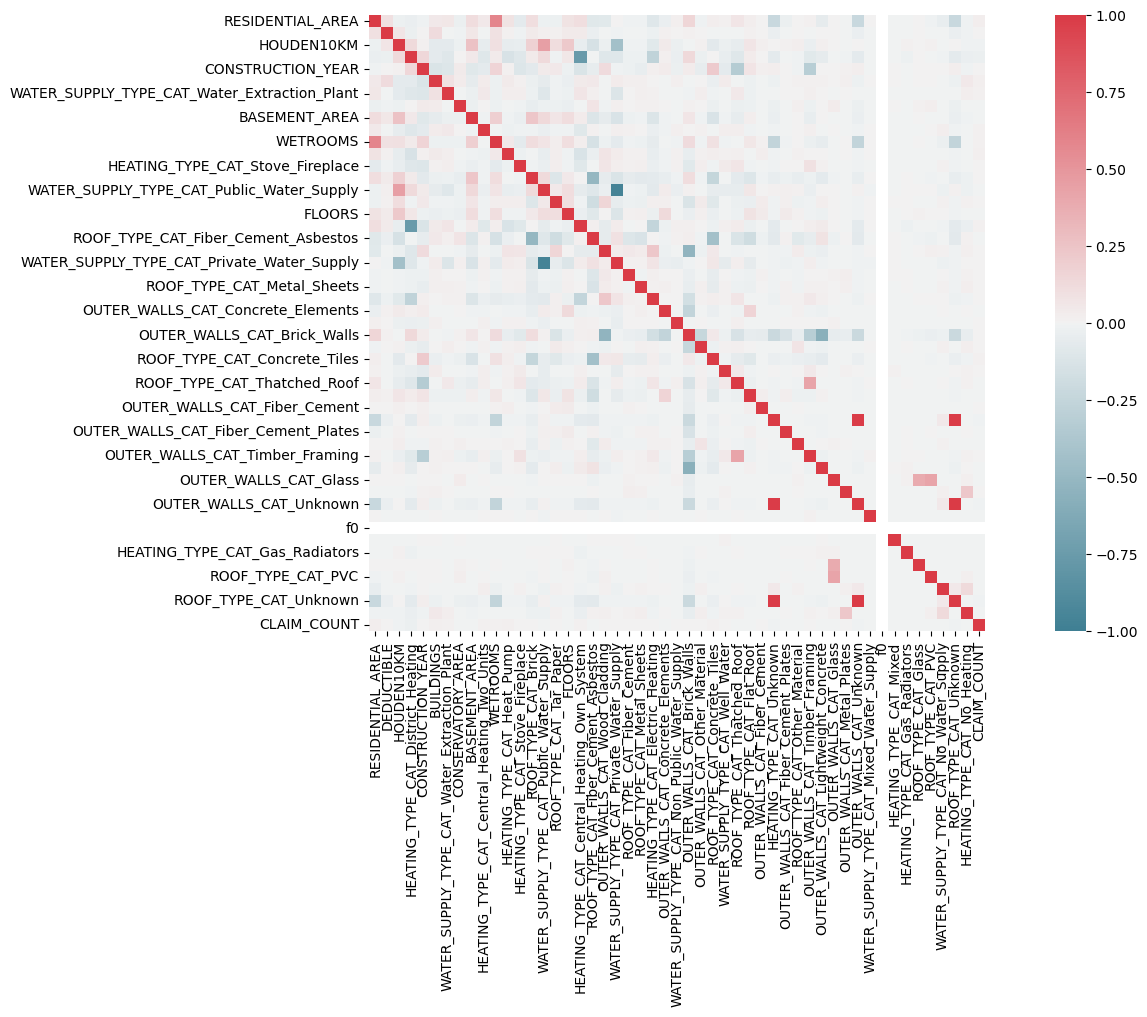

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(18, 8))
sns.heatmap(data_selected.corr(), mask=np.zeros_like(data_selected.corr(), dtype=bool),
            cmap=sns.diverging_palette(220, 10, as_cmap=True), vmin=-1.0, vmax=1.0,
            square=True)